# EDA: Анализ датасета `ai-forever/ru-reviews-classification`

Датасет содержит отзывы с Wildberries, размеченные на три класса тональности.
Цель анализа — понять распределение классов, характеристики текстов и качество данных.

In [26]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ds = load_dataset("ai-forever/ru-reviews-classification")
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()

print(f"Train: {len(df_train)} строк")
print(f"Test:  {len(df_test)} строк")
df_train.head()

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/ai-forever/ru-reviews-classification/resolve/0f67d914f396ce22917dc6463ec619799b3b08d2/ru-reviews-classification.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since ai-forever/ru-reviews-classification couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\anark\.cache\huggingface\datasets\ai-forever___ru-reviews-classification\default\0.0.0\0f67d914f396ce22917dc6463ec619799b3b08d2 (last modified on Fri May 22 13:37:10 2026).


Train: 45000 строк
Test:  15000 строк


,text,label_text,label,id
0,всё пришло спасибо. только немного короче чем ...,positive,2,64971
1,The color of the dress is not the same as in t...,neutral,1,34896
2,"Заказывала белый цвет, пришёл какой то персико...",neutral,1,46253
3,Приятное к телу. Но в бюсте на размер больше. ...,negative,0,19034
4,Не пришла деньги через спор вернули,neutral,1,36063


## 1. Распределение классов

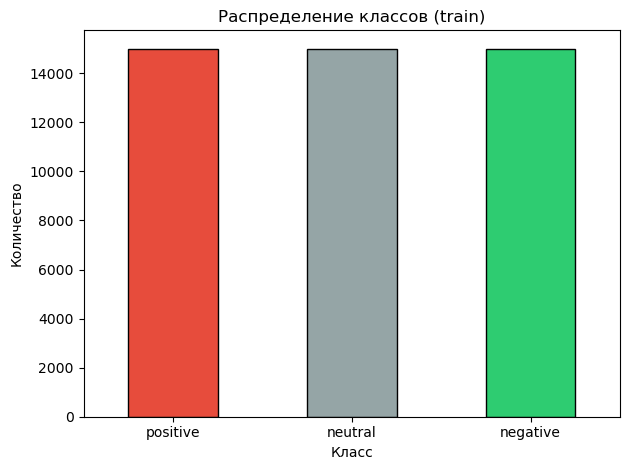

label_name
positive    15000
neutral     15000
negative    15000
Name: count, dtype: int64


In [27]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df_train["label_name"] = df_train["label"].map(label_map)

counts = df_train["label_name"].value_counts()
counts.plot(kind="bar", color=["#e74c3c","#95a5a6","#2ecc71"], edgecolor="black")
plt.title("Распределение классов (train)")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(counts)

## 2. Длина отзывов

In [28]:
df_train["text_len"] = df_train["text"].str.len()
df_train["word_count"] = df_train["text"].str.split().str.len()

df_train.groupby("label_name")[["text_len","word_count"]].describe().round(1)

text_len                                                word_count  \
              count   mean    std  min   25%    50%    75%     max      count   
label_name                                                                      
negative    15000.0  148.8  141.1  1.0  62.0  103.0  182.0  1000.0    15000.0   
neutral     15000.0  128.7  125.1  1.0  48.0   89.0  162.0  1000.0    15000.0   
positive    15000.0  122.2  109.3  1.0  51.0   91.0  157.0  1000.0    15000.0   

                                                     
            mean   std  min  25%   50%   75%    max  
label_name                                           
negative    23.1  22.3  1.0  9.0  16.0  28.0  192.0  
neutral     20.0  19.8  1.0  7.0  14.0  25.0  175.0  
positive    18.3  17.0  1.0  7.0  13.0  24.0  171.0

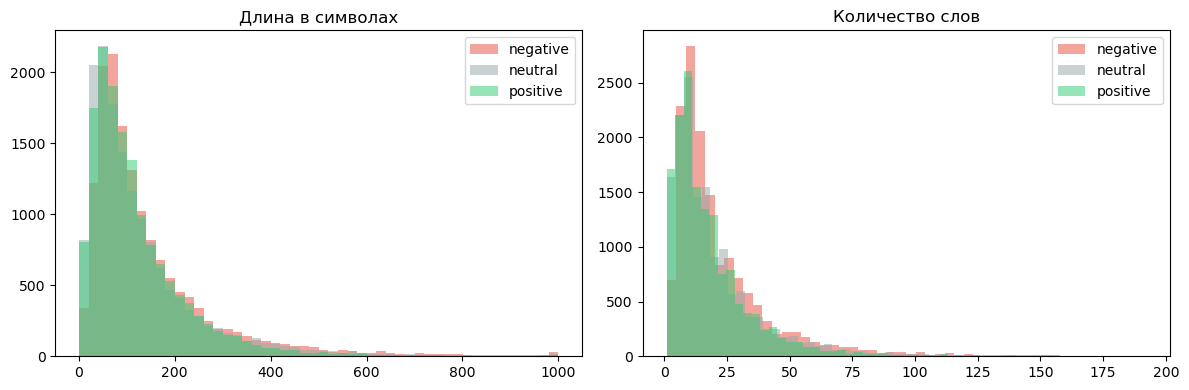

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ["text_len", "word_count"],
                           ["Длина в символах", "Количество слов"]):
    for label, color in zip(["negative","neutral","positive"],
                             ["#e74c3c","#95a5a6","#2ecc71"]):
        subset = df_train[df_train["label_name"] == label][col]
        ax.hist(subset, bins=50, alpha=0.5, label=label, color=color)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Примеры из каждого класса

In [30]:
for label in ["negative", "neutral", "positive"]:
    print(f"\n{'='*60}")
    print(f"  {label.upper()}")
    print('='*60)
    samples = df_train[df_train["label_name"] == label]["text"].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"\n[{i}] {text[:300]}")


  NEGATIVE

[1] Леггинсы короткие на рост 170 см, при чем внизу не облегают. Вверху как-то топорщатся, некрасиво. Носить не буду.

[2] плохо! качество материала ужасное! не похоже на то, что на фотке вообще! сидит плохо + велика

[3] Пришло серого цвета .Мне нужна белая .

  NEUTRAL

[1] очень большая в плечах (((

[2] Заказ получила. Но не особо осталась довольна, сложна кофта была как попало. И самый большой минус это шов во всю спину,конечно неожиданный поворот, на фото это не видно было. Ну а так качество впрочем не плохое, казалось что ткань плотная на фото а на самом деле она легенькая, тоненькая

[3] размер не соответствут

  POSITIVE

[1] Заказ пришел за 20 дней до Улан-Удэ. Хорошего качества. Швы ровные, теплая, мягкая. Приятная к телу.  Рукава короткие на рост 175. В целом заказом довольна.

[2] спасибо большое!очень хороший товар.

[3] На рост 179 размер М коротковат и в руках и  в длину. На 174 чуть получше, но тоже не идеально. В остальном, очень приятная кенгуруха, мягка

## 4. Confusion Matrix модели

F1-macro: 0.7618468614195263
Accuracy: 0.7606666666666667


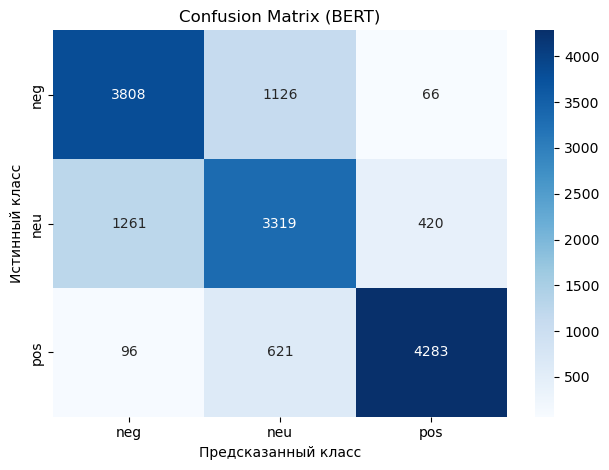

In [ ]:
import json, os
import matplotlib.pyplot as plt
import seaborn as sns

metrics_path = "../artifacts/bert_metrics.json"
if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)

    print("F1-macro:", metrics.get("f1_macro"))
    print("Accuracy:", metrics.get("accuracy"))

    cm = metrics.get("confusion_matrix")
    if cm:
        cm_matrix = cm["matrix"]
        sns.heatmap(cm_matrix, annot=True, fmt="d",
                    xticklabels=["neg", "neu", "pos"],
                    yticklabels=["neg", "neu", "pos"],
                    cmap="Blues")
        plt.title("Confusion Matrix (BERT)")
        plt.ylabel("Истинный класс")
        plt.xlabel("Предсказанный класс")
        plt.tight_layout()
        plt.show()
else:
    print("Сначала запусти: python -m src.train --bert")

## Вывод

- **Датасет**: `ai-forever/ru-reviews-classification` — отзывы Wildberries.  
  Три сбалансированных класса по **15 000** примеров в train-split.  
  Средняя длина отзыва: negative ≈ 149 симв. / 23 слова, neutral ≈ 129 / 20, positive ≈ 122 / 18.

- **Baseline (TF-IDF + LogisticRegression)**: быстрый, интерпретируемый старт.

- **rubert-tiny2**: превышает baseline по **F1-macro: 0.7618** (Accuracy: 0.7607).  
  Цель ≥ 0.80 пока не достигнута; для улучшения результата можно:
  - увеличить число эпох (5–7 вместо 3),
  - поднять `max_length` (256 вместо 128),
  - применить аугментацию данных для класса `neutral`.

- **Confusion matrix**: больше всего ошибок ожидается на границе  
  `neutral ↔ negative` и `neutral ↔ positive` — это типично для трёхклассовой тональности.